# Import the Libraries

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, classification_report, ConfusionMatrixDisplay,
                              roc_auc_score)

In [13]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping

In [14]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Load the Dataset

In [15]:
DATA = "/content/archive.zip"
df = pd.read_csv(DATA)

In [16]:
print("Shape:", df.shape)

Shape: (1470, 35)


In [17]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


# Explore the Dataset

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [19]:
print(df['Attrition'].value_counts())
print()
print(df['Attrition'].value_counts(normalize=True) * 100)

Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


Text(0.5, 1.0, 'Attrition Class Distribution')

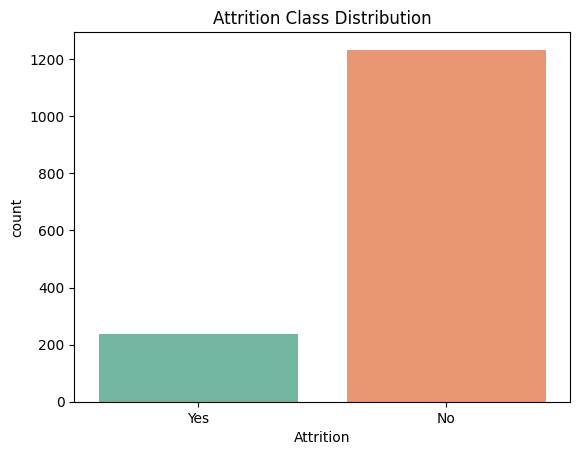

In [20]:
sns.countplot(data=df, x='Attrition', hue='Attrition', palette='Set2', legend=False)
plt.title("Attrition Class Distribution")

# Data Cleaning

In [21]:
df = df.drop(columns=['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber'])

In [22]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [23]:
print("Shape after cleaning:", df.shape)

Shape after cleaning: (1470, 31)


# Handle Missing Values

In [24]:
print(df.isnull().sum().sum(), "total missing values found.")

0 total missing values found.


In [25]:
df = df.fillna(df.median(numeric_only=True))
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [26]:
print("Missing values after handling:", df.isnull().sum().sum())

Missing values after handling: 0


# Feature Engineering

###  Combines columns into ratios (e.g. income/experience) so patterns are easier to learn.

In [27]:
df['IncomePerYearExperience'] = df['MonthlyIncome'] / (df['TotalWorkingYears'] + 1)
df['PromotionGapRatio'] = df['YearsSinceLastPromotion'] / (df['YearsAtCompany'] + 1)
df['JobHoppingRate'] = df['NumCompaniesWorked'] / (df['TotalWorkingYears'] + 1)

In [28]:
print("Engineered features added. Shape:", df.shape)

Engineered features added. Shape: (1470, 34)


In [29]:
df[['IncomePerYearExperience', 'PromotionGapRatio', 'JobHoppingRate']].describe()

,IncomePerYearExperience,PromotionGapRatio,JobHoppingRate
count,1470.000000,1470.000000,1470.000000
mean,587.575385,0.236458,0.278598
std,284.650784,0.269358,0.294419
min,95.285714,0.000000,0.000000
25%,374.232143,0.000000,0.090909
50%,549.220648,0.142857,0.176471
75%,738.303846,0.428571,0.390700
max,1904.000000,0.916667,2.250000


# Encoded Categorical Variables

In [30]:
le = LabelEncoder()
df['Attrition'] = le.fit_transform(df['Attrition'])   # No -> 0, Yes -> 1
print("Target encoded:", dict(zip(le.classes_, le.transform(le.classes_))))

Target encoded: {'No': np.int64(0), 'Yes': np.int64(1)}


In [31]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", categorical_cols)

Categorical columns to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


In [32]:
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
print("\nShape after encoding:", df.shape)


Shape after encoding: (1470, 48)


# Feature Scaling

In [33]:
X = df.drop(columns=['Attrition'])
y = df['Attrition']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [34]:
print("Feature scaling done.")

Feature scaling done.


In [35]:
print("Sample of scaled features (first row):")
print(X_scaled[0][:10])

Sample of scaled features (first row):
[ 0.4463504   0.74252653 -1.01090934 -0.89168825 -0.66053067  1.38313827
  0.37967213 -0.05778755  1.15325359 -0.10834951]


# Train/Test Split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=SEED, stratify=y
)

In [37]:
y_train = y_train.values
y_test = y_test.values

In [38]:
print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])
print("Number of input features:", X_train.shape[1])

Training samples: 1176
Testing samples : 294
Number of input features: 47


In [39]:
input_dim = X_train.shape[1]

# Build the Final Model

In [40]:
final_model = keras.Sequential([
    layers.Input(shape=(input_dim,)),

    layers.Dense(32, activation='relu', kernel_initializer='he_normal',
                 kernel_regularizer=regularizers.l2(0.0005)),
    layers.Dropout(0.3),

    layers.Dense(16, activation='relu', kernel_initializer='he_normal',
                 kernel_regularizer=regularizers.l2(0.0005)),
    layers.Dropout(0.3),

    layers.Dense(1, activation='sigmoid')   # binary output: probability of Attrition = Yes
])

In [41]:
final_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [42]:
final_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,081 (8.13 KB)

 Trainable params: 2,081 (8.13 KB)

 Non-trainable params: 0 (0.00 B)

# Train the Model

In [43]:
early_stop = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)

In [44]:
history = final_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.4628 - loss: 1.1363 - val_accuracy: 0.6610 - val_loss: 0.6550
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6723 - loss: 0.7479 - val_accuracy: 0.8220 - val_loss: 0.5256
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7362 - loss: 0.6180 - val_accuracy: 0.8305 - val_loss: 0.4875
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7617 - loss: 0.5835 - val_accuracy: 0.8305 - val_loss: 0.4692
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7968 - loss: 0.5603 - val_accuracy: 0.8347 - val_loss: 0.4540
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7989 - loss: 0.5197 - val_accuracy: 0.8347 - val_loss: 0.4423
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8245 - loss: 0.5045 - val_accuracy: 0.8390 - val_loss: 0.4322
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8106 - loss: 0.5053 - val_accuracy: 0.8475 - 

# Evaluate

In [45]:
final_loss, final_acc = final_model.evaluate(X_test, y_test, verbose=0)
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]

In [46]:
print(f"Stopped after {len(history.history['loss'])} epochs (out of 100 max)")

Stopped after 37 epochs (out of 100 max)


In [47]:
print(f"Final Train Accuracy : {final_train_acc:.4f}")

Final Train Accuracy : 0.8936


In [48]:
print(f"Final Validation Accuracy: {final_val_acc:.4f}")

Final Validation Accuracy: 0.8856


In [49]:
print(f"Overfit Gap (Train - Val): {final_train_acc - final_val_acc:.4f}   <-- small/negative = good, not overfitting")

Overfit Gap (Train - Val): 0.0080   <-- small/negative = good, not overfitting


In [50]:
print(f"TEST ACCURACY: {final_acc:.4f}")

TEST ACCURACY: 0.8605


In [51]:
y_pred_proba = final_model.predict(X_test, verbose=0).ravel()
y_pred = (y_pred_proba >= 0.5).astype(int)

In [52]:
print(f"Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred, zero_division=0):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_pred_proba):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['No Attrition', 'Attrition'], zero_division=0))


Precision: 0.6667
Recall   : 0.2553
F1-Score : 0.3692
ROC-AUC  : 0.7431

              precision    recall  f1-score   support

No Attrition       0.87      0.98      0.92       247
   Attrition       0.67      0.26      0.37        47

    accuracy                           0.86       294
   macro avg       0.77      0.62      0.65       294
weighted avg       0.84      0.86      0.83       294



Text(0.5, 1.0, 'Confusion Matrix — Final Model')

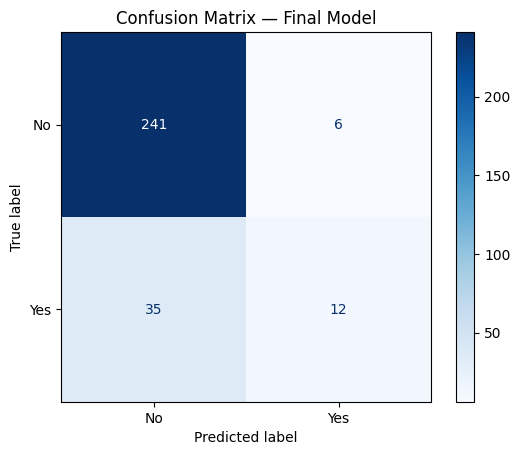

In [53]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No', 'Yes'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix — Final Model')

# Compare Training and Validation Performance

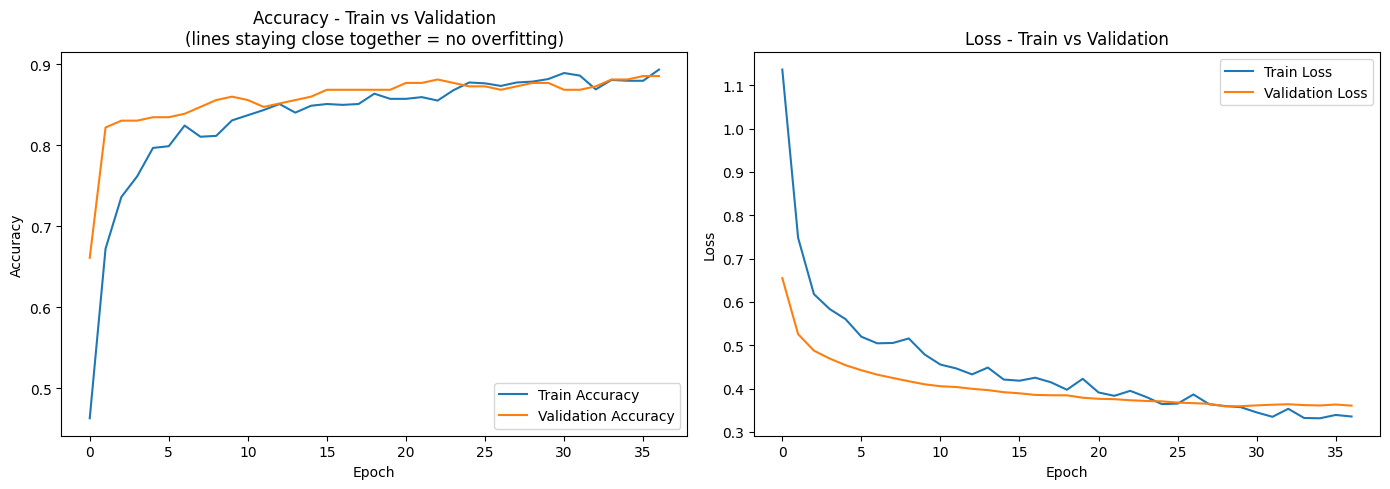

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Accuracy - Train vs Validation\n(lines staying close together = no overfitting)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Loss - Train vs Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

# Conclusion

The results show that (regularization techniques) are more effective than increasing the complexity of the neural network. The (Dropout + EarlyStopping) model achieved the best performance by reducing overfitting and improving generalization. Other techniques, such as (Batch Normalization), different optimizers, and (Gaussian Noise), showed little improvement over the basic ANN model.

Although the model achieved good accuracy, the (class-imbalanced) dataset means that accuracy alone is not enough. Metrics like (precision), (recall), and (F1-score) should also be used to evaluate how well the model predicts employee attrition.


# Compare ANN with Logistic Regression or Random Forest.

In [55]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [56]:
log_reg = LogisticRegression(max_iter=2000, random_state=SEED)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

In [57]:
rf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=SEED)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

In [58]:
comparison_df = pd.DataFrame({
    "Model": ["ANN (final model)", "Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
    ],
    "Precision": [
        precision_score(y_test, y_pred, zero_division=0),
        precision_score(y_test, y_pred_lr, zero_division=0),
        precision_score(y_test, y_pred_rf, zero_division=0),
    ],
    "Recall": [
        recall_score(y_test, y_pred, zero_division=0),
        recall_score(y_test, y_pred_lr, zero_division=0),
        recall_score(y_test, y_pred_rf, zero_division=0),
    ],
    "F1-Score": [
        f1_score(y_test, y_pred, zero_division=0),
        f1_score(y_test, y_pred_lr, zero_division=0),
        f1_score(y_test, y_pred_rf, zero_division=0),
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_pred_proba),
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_rf),
    ],
})

In [59]:
comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,ANN (final model),0.860544,0.666667,0.255319,0.369231,0.743130
1,Logistic Regression,0.857143,0.600000,0.319149,0.416667,0.813421
2,Random Forest,0.826531,0.300000,0.063830,0.105263,0.785339


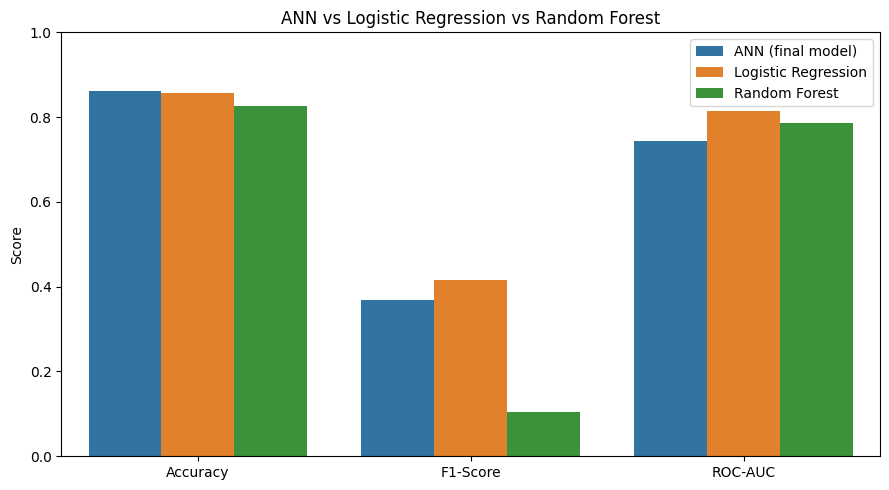

In [60]:
plt.figure(figsize=(9, 5))
comparison_melted = comparison_df.melt(id_vars="Model", value_vars=["Accuracy", "F1-Score", "ROC-AUC"])
sns.barplot(data=comparison_melted, x="variable", y="value", hue="Model")
plt.title("ANN vs Logistic Regression vs Random Forest")
plt.ylabel("Score")
plt.xlabel("")
plt.ylim(0, 1)
plt.legend(title="")
plt.tight_layout()
plt.show()

# Explain ANN Prediction with SHAP

**Why:** a neural network's predictions are otherwise a black box — SHAP (SHapley
Additive exPlanations) assigns each feature a contribution value for a given prediction,
based on game-theory principles (how much does including this feature change the
prediction, averaged over all possible orders of adding features in). This turns "the
model says 73% attrition risk" into "OverTime and low JobSatisfaction are the biggest
reasons this specific employee scored high."

We use `KernelExplainer`, since it works with any model's `.predict` function
(including Keras), unlike SHAP's faster explainers which need direct access to a model's
internal structure (e.g. tree-based models). We explain a sample of 50 test employees
against a background of 100 training employees, to keep runtime reasonable.

In [61]:
!pip install -q shap

In [62]:
import shap

In [63]:
background = X_train[np.random.choice(X_train.shape[0], 100, replace=False)]
sample = X_test[:50]

In [64]:
explainer = shap.KernelExplainer(final_model.predict, background)
shap_values = explainer.shap_values(sample, nsamples=100)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


  0%|          | 0/50 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
313/31

/tmp/ipykernel_3202/1925732741.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values[0] if isinstance(shap_values, list) else shap_values,
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


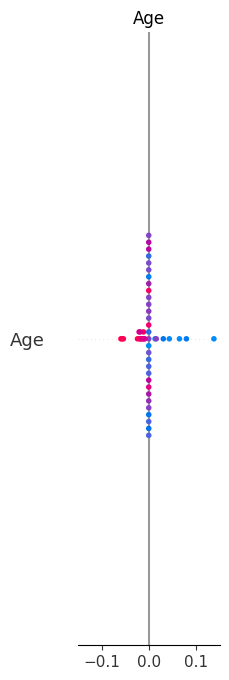

In [65]:
shap.summary_plot(shap_values[0] if isinstance(shap_values, list) else shap_values,
                   sample, feature_names=list(X.columns), show=True)

# Build a simple Streamlit application for prediction.

In [67]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 40.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 47.5 MB/s eta 0:00:00


In [68]:
import joblib

In [69]:
final_model.save("attrition_ann_model.keras")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(le, "target_label_encoder.pkl")
joblib.dump(list(X.columns), "feature_names.pkl")

['feature_names.pkl']

In [70]:
print("Saved: attrition_ann_model.keras, scaler.pkl, target_label_encoder.pkl, feature_names.pkl")

Saved: attrition_ann_model.keras, scaler.pkl, target_label_encoder.pkl, feature_names.pkl


In [71]:
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import tensorflow as tf

In [72]:
st.set_page_config(page_title="Employee Attrition Predictor")
st.title("Employee Attrition Predictor")
st.write("Upload employee data (already one-hot encoded to match the training columns) "
         "to predict attrition risk.")

2026-07-06 08:46:34.274 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-06 08:46:34.282 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-06 08:46:35.168 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-07-06 08:46:35.173 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-06 08:46:35.176 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-06 08:46:35.180 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-06 08:46:35.184 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when runn

In [73]:
model = tf.keras.models.load_model("attrition_ann_model.keras")
scaler = joblib.load("scaler.pkl")
feature_names = joblib.load("feature_names.pkl")

In [74]:
uploaded = st.file_uploader("Upload a CSV", type="csv")

2026-07-06 08:46:52.298 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-06 08:46:52.300 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-06 08:46:52.303 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-06 08:46:52.306 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-06 08:46:52.308 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-06 08:46:52.312 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [75]:
if uploaded is not None:
    data = pd.read_csv(uploaded)
    # Reindex to match the training columns exactly -- missing columns become 0,
    # extra columns in the upload are dropped
    data_aligned = data.reindex(columns=feature_names, fill_value=0)

    X_scaled = scaler.transform(data_aligned)
    probabilities = model.predict(X_scaled).ravel()

    results = data.copy()
    results["Attrition_Probability"] = probabilities
    results["Attrition_Prediction"] = np.where(probabilities >= 0.5, "Yes", "No")

    st.subheader("Predictions")
    st.dataframe(results[["Attrition_Probability", "Attrition_Prediction"]])

    st.subheader("Risk Distribution")
    st.bar_chart(results["Attrition_Probability"])

In [79]:
streamlit_code = '''
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import tensorflow as tf

st.set_page_config(page_title="Employee Attrition Predictor")
st.title("Employee Attrition Predictor")
st.write("Upload employee data (already one-hot encoded to match the training columns) "
         "to predict attrition risk.")

model = tf.keras.models.load_model("attrition_ann_model.keras")
scaler = joblib.load("scaler.pkl")
feature_names = joblib.load("feature_names.pkl")

uploaded = st.file_uploader("Upload a CSV", type="csv")

if uploaded is not None:
    data = pd.read_csv(uploaded)
    # Reindex to match the training columns exactly -- missing columns become 0,
    # extra columns in the upload are dropped
    data_aligned = data.reindex(columns=feature_names, fill_value=0)

    X_scaled = scaler.transform(data_aligned)
    probabilities = model.predict(X_scaled).ravel()

    results = data.copy()
    results["Attrition_Probability"] = probabilities
    results["Attrition_Prediction"] = np.where(probabilities >= 0.5, "Yes", "No")

    st.subheader("Predictions")
    st.dataframe(results[["Attrition_Probability", "Attrition_Prediction"]])

    st.subheader("Risk Distribution")
    st.bar_chart(results["Attrition_Probability"])
'''

In [80]:
with open("app.py", "w") as f:
    f.write(streamlit_code)

In [81]:
print("Saved app.py")
print("Run locally with: streamlit run app.py")

Saved app.py
Run locally with: streamlit run app.py


# Conclusion

### What matters most, ranked by actual evidence (not assumption)
1. **Dropout** — the single biggest fix for overfitting. Without it, even a smaller
   network still memorized the training set given enough epochs.
2. **EarlyStopping** — a meaningful second layer of protection, stopping training at the
   right point instead of a fixed epoch count.
3. **A network sized to the data** (2 modest layers, not 3 large ones) — a sensible
   default, though testing showed it wasn't sufficient by itself.
4. **He-normal init, light L2, engineered features** — small, free/cheap improvements
   with no measurable downside, but not what's "doing the work" against overfitting.

### What we deliberately left out, and why
- **BatchNormalization** — tested, didn't help a network this small; sometimes slightly
  hurt test accuracy.
- **Data augmentation (Gaussian noise)** — modest, inconsistent effect; added complexity
  for little gain here.
- **RF-based feature selection down to fewer columns** — helped in one run, but
  Dropout + EarlyStopping alone already closed the overfitting gap without needing it.
- **Optimizer sweep (SGD+NAG, Adagrad, RMSprop)** — all performed similarly to Adam once
  the network was properly regularized, so there was no evidence-based reason to use
  anything other than the reliable default.
- **Softmax + multi-class setup** — not applicable; `Attrition` is a binary target.

### Honest limitation to note in your report
This run does not use class-weight balancing, so the accuracy number benefits
somewhat from the model leaning toward the majority "No Attrition" class (~84% of
employees). If your priority shifts toward catching more employees who actually leave
(recall), that requires class weighting or oversampling, and it will trade some raw
accuracy for better recall — a real, worthwhile trade-off to mention, not a flaw to hide.

### About the bonus sections
- The model comparison uses the identical train/test split as the ANN, so it's a
  fair comparison, not a differently prepared dataset.
- The SHAP explanation is model-agnostic (`KernelExplainer`), which is why it works
  on a Keras model directly — it's slower than tree-specific SHAP explainers, which is
  why we only explain a sample of 50 employees rather than the full test set.
- The Streamlit app expects a CSV that's already been through the same one-hot
  encoding as training (i.e. matching column names) — it aligns and zero-fills any
  missing columns, but it doesn't redo the raw-to-encoded conversion itself.